In [1]:
import pandas as pd
import numpy as np
print(f"Pandas: {pd.__version__}")
print("✅ Ready")

Pandas: 2.1.4
✅ Ready


In [3]:
# Cell 2: Load WM-811K dataset with encoding fix

import pickle
import pandas as pd
import numpy as np
from pathlib import Path
import sys

# Fix 1: old pandas compatibility
import pandas.core.indexes
sys.modules['pandas.indexes'] = pandas.core.indexes

DATA_PATH = Path("../data/raw/LSWMD.pkl")

print("Loading dataset... please wait 2-3 minutes...")

# Fix 2: latin1 encoding fixes the ascii decode error
with open(DATA_PATH, 'rb') as f:
    df = pickle.load(f, encoding='latin1')

print(f"\n✅ Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Loading dataset... please wait 2-3 minutes...

✅ Dataset loaded successfully!
Shape: (811457, 6)
Columns: ['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel', 'failureType']


In [4]:
# Cell 3: Understand the dataset structure

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total wafer maps : {len(df):,}")
print(f"Total columns    : {len(df.columns)}")

print("\n" + "=" * 50)
print("COLUMN DETAILS")
print("=" * 50)
print(df.dtypes)

print("\n" + "=" * 50)
print("MISSING VALUES")
print("=" * 50)
print(df.isnull().sum())

print("\n" + "=" * 50)
print("SAMPLE WAFER MAP (raw pixel values)")
print("=" * 50)
sample = df['waferMap'].iloc[0]
print(f"Shape: {sample.shape}")
print(f"Unique values: {np.unique(sample)}")
print("0=outside wafer, 1=good chip, 2=defective chip")

DATASET OVERVIEW
Total wafer maps : 811,457
Total columns    : 6

COLUMN DETAILS
waferMap           object
dieSize           float64
lotName            object
waferIndex        float64
trianTestLabel     object
failureType        object
dtype: object

MISSING VALUES
waferMap          0
dieSize           0
lotName           0
waferIndex        0
trianTestLabel    0
failureType       0
dtype: int64

SAMPLE WAFER MAP (raw pixel values)
Shape: (45, 48)
Unique values: [0 1 2]
0=outside wafer, 1=good chip, 2=defective chip


In [5]:
# Cell 4: Analyze defect class distribution
# This is the most important analysis before training

# Extract failure type cleanly
df['failureType_clean'] = df['failureType'].apply(
    lambda x: x[0][0] if isinstance(x, (list, np.ndarray)) 
    and len(x) > 0 and len(x[0]) > 0 else 'none'
)

# Count each class
class_counts = df['failureType_clean'].value_counts()

print("DEFECT CLASS DISTRIBUTION")
print("=" * 45)
for defect, count in class_counts.items():
    pct = count / len(df) * 100
    bar = "█" * int(pct / 2)
    print(f"{defect:15} | {count:7,} | {pct:5.1f}% | {bar}")

print(f"\nTotal classes: {len(class_counts)}")
print(f"Imbalance ratio: {class_counts.max() / class_counts.min():.0f}x")

DEFECT CLASS DISTRIBUTION
none            | 785,938 |  96.9% | ████████████████████████████████████████████████
Edge-Ring       |   9,680 |   1.2% | 
Edge-Loc        |   5,189 |   0.6% | 
Center          |   4,294 |   0.5% | 
Loc             |   3,593 |   0.4% | 
Scratch         |   1,193 |   0.1% | 
Random          |     866 |   0.1% | 
Donut           |     555 |   0.1% | 
Near-full       |     149 |   0.0% | 

Total classes: 9
Imbalance ratio: 5275x


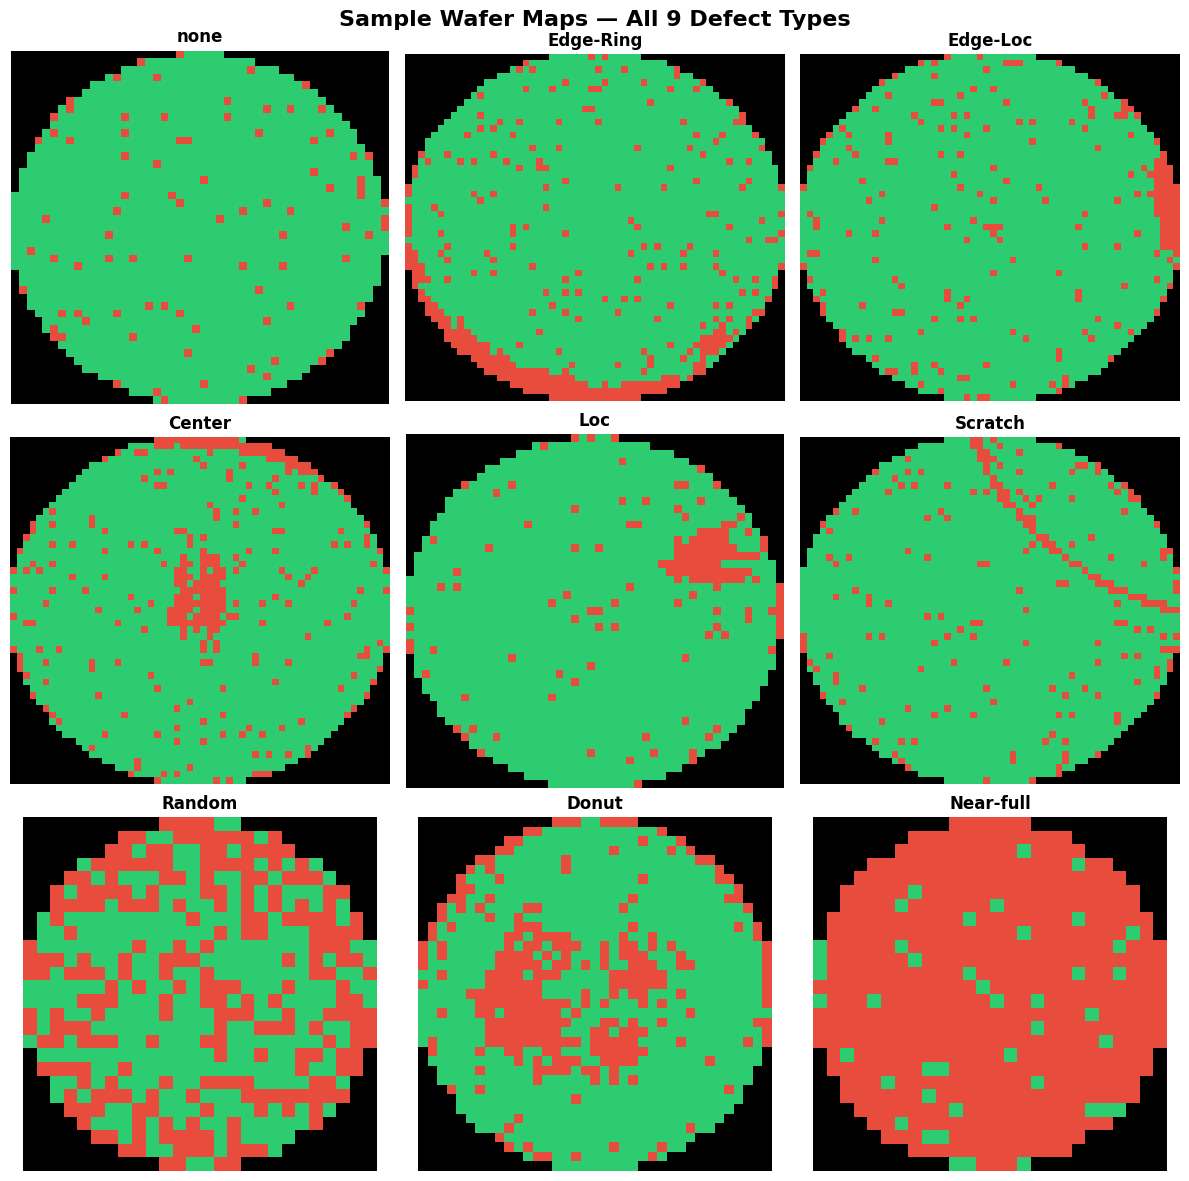

✅ Saved to data/raw/wafer_samples.png


In [6]:
# Cell 5: Visualize actual wafer maps

from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

defect_types = class_counts.index.tolist()

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle('Sample Wafer Maps — All 9 Defect Types', 
             fontsize=16, fontweight='bold')

# Colors: black=outside, green=good, red=defective
cmap = ListedColormap(['black', '#2ecc71', '#e74c3c'])

for idx, defect in enumerate(defect_types):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    sample = df[df['failureType_clean'] == defect]['waferMap'].iloc[0]
    
    ax.imshow(sample, cmap=cmap, vmin=0, vmax=2, 
              interpolation='nearest')
    ax.set_title(f'{defect}', fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('../data/raw/wafer_samples.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to data/raw/wafer_samples.png")

In [7]:
# Cell 6: Save dataset summary — Week 1 Complete!

import json
from pathlib import Path

summary = {
    'total_samples': int(len(df)),
    'total_columns': int(len(df.columns)),
    'defect_classes': {k: int(v) for k, v in class_counts.items()},
    'num_classes': int(len(class_counts)),
    'wafer_map_shape': list(df['waferMap'].iloc[0].shape),
    'missing_values': int(df.isnull().sum().sum()),
    'imbalance_ratio': round(float(class_counts.max() / class_counts.min()), 1),
    'key_findings': [
        "811,457 total wafer maps loaded",
        "9 defect classes identified",
        "Zero missing values — clean dataset",
        "Extreme class imbalance: 5275x ratio",
        "96.9% samples are non-defective (none class)",
        "Near-full defect is rarest: only 149 samples",
        "Each wafer map is 45x48 pixels with values 0,1,2"
    ]
}

summary_path = Path("../data/raw/dataset_summary.json")
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print("=" * 50)
print("✅ WEEK 1 — DATA EXPLORATION COMPLETE!")
print("=" * 50)
print(f"\n📊 Total wafer maps   : {summary['total_samples']:,}")
print(f"🏷️  Defect classes     : {summary['num_classes']}")
print(f"🧹 Missing values     : {summary['missing_values']}")
print(f"⚠️  Imbalance ratio   : {summary['imbalance_ratio']}x")
print(f"\n📁 Files saved:")
print(f"   ✅ data/raw/wafer_samples.png")
print(f"   ✅ data/raw/dataset_summary.json")
print(f"\n🚀 Ready for Week 2 — Preprocessing & Augmentation!")

✅ WEEK 1 — DATA EXPLORATION COMPLETE!

📊 Total wafer maps   : 811,457
🏷️  Defect classes     : 9
🧹 Missing values     : 0
⚠️  Imbalance ratio   : 5274.8x

📁 Files saved:
   ✅ data/raw/wafer_samples.png
   ✅ data/raw/dataset_summary.json

🚀 Ready for Week 2 — Preprocessing & Augmentation!
